In [68]:
#Import necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#For maps
import folium

#time series forecasting library (to automatically handle seasonality)
from prophet import Prophet

#LightGBM (build one tree after another, and each tree tries to fix the mistakes of the previos trees)
import lightgbm as lgb


from sklearn.metrics import mean_absolute_error, mean_squared_error

#matplotlib styling
plt.rc('figure', autolayout=True, figsize=(8, 5))
plt.rc('axes', facecolor='white', edgecolor='black',
       grid=True, linewidth=1, titlesize=16, titleweight='bold',
       labelsize=12, labelweight='bold')
plt.rc('xtick', direction='out', labelsize=10)
plt.rc('ytick', direction='out', labelsize=10)
plt.rc('legend', fontsize=12)
plt.rc('lines', linewidth=2, markersize=6)
plt.rc('animation', html='html5')
%matplotlib inline

In [69]:
weather = pd.read_csv("/content/drive/MyDrive/DATASET/Weather-Sri_Lanka/SriLanka_Weather_Dataset.csv")
weather.columns

Index(['time', 'weathercode', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'apparent_temperature_max',
       'apparent_temperature_min', 'apparent_temperature_mean', 'sunrise',
       'sunset', 'shortwave_radiation_sum', 'precipitation_sum', 'rain_sum',
       'snowfall_sum', 'precipitation_hours', 'windspeed_10m_max',
       'windgusts_10m_max', 'winddirection_10m_dominant',
       'et0_fao_evapotranspiration', 'latitude', 'longitude', 'elevation',
       'country', 'city'],
      dtype='object')

In [70]:
#change the time format (using it as a index)
weather['time'] = pd.to_datetime(weather['time'])

print(weather.shape)

print(f"Date range: {weather['time'].min()} - {weather['time'].max()}")

(147480, 24)
Date range: 2010-01-01 00:00:00 - 2023-06-17 00:00:00


In [71]:
#Unique city and coordinates
cities = weather.groupby('city')[['latitude', 'longitude']].first().reset_index()

print(f"total city: {len(cities)}")
cities.head()

total city: 30


,city,latitude,longitude
0,Athurugiriya,6.900002,79.899994
1,Badulla,7.099998,81.100006
2,Bentota,6.500000,80.000000
3,Colombo,7.000000,79.899994
4,Galle,6.099998,80.200010


In [72]:
#Folium Map
m_1 = folium.Map(
    width=600, height=400,
    location=[7.877083, 80.697917],   # Sri Lanka
    tiles='cartodbpositron',
    zoom_start=7,
    zoom_control=False,
    scrollWheelZoom=False,
    dragging=True
)

#City marker
for _, row in cities.iterrows():
    folium.Circle(
        location=[row['latitude'], row['longitude']],
        radius=2000,          # radius in metres
        color='steelblue',
        fill=True,
        fill_opacity=0.6
    ).add_child(folium.Popup(row['city'])).add_to(m_1)

m_1

# **Data Exploration ( Ratnapura )**

In [73]:
#Data cleaning by using Ratnapura data
weather_ratnapura = (
    weather[weather['city'] == 'Ratnapura']
    .drop(columns=[
        'country', 'temperature_2m_max', 'temperature_2m_min',
        'sunrise', 'sunset', 'apparent_temperature_max',
        'apparent_temperature_min', 'snowfall_sum',
        'longitude', 'latitude', 'elevation'
    ])
    .assign(time=lambda df: pd.to_datetime(df['time']))
    .set_index('time')
    .sort_index()
)

In [74]:
weather_ratnapura.sort_index()
print(weather_ratnapura.shape)

(4916, 12)


In [75]:
weather_ratnapura.columns


Index(['weathercode', 'temperature_2m_mean', 'apparent_temperature_mean',
       'shortwave_radiation_sum', 'precipitation_sum', 'rain_sum',
       'precipitation_hours', 'windspeed_10m_max', 'windgusts_10m_max',
       'winddirection_10m_dominant', 'et0_fao_evapotranspiration', 'city'],
      dtype='object')

**Monthly Rainfall**

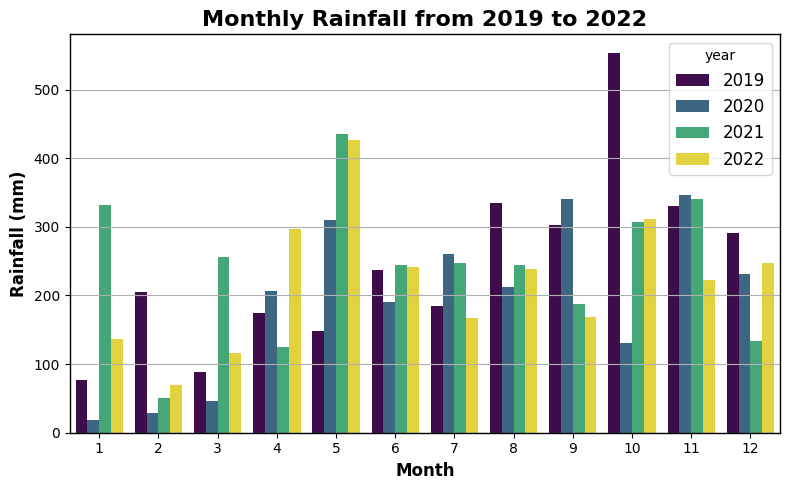

In [76]:
annual_rainfall = weather_ratnapura.groupby([weather_ratnapura.index.year, weather_ratnapura.index.month])['rain_sum'].sum()
annual_rainfall.index.names = ['year', 'month']

monthly_ranfall = annual_rainfall.loc[2019:2022].reset_index()

sns.barplot(
    x='month',
    y='rain_sum',
    hue='year',
    data= monthly_ranfall,
    palette='viridis'
)

plt.title('Monthly Rainfall from 2019 to 2022')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.show()


**Temp HeatMap**

In [77]:
grouped_temperature = weather_ratnapura.groupby([weather_ratnapura.index.year, weather_ratnapura.index.month])['temperature_2m_mean'].mean()
grouped_temperature.index.names = ['year', 'month']
average_temp = grouped_temperature.reset_index()

average_temp.head()

,year,month,temperature_2m_mean
0,2010,1,25.116129
1,2010,2,25.792857
2,2010,3,26.416129
3,2010,4,26.203333
4,2010,5,25.870968


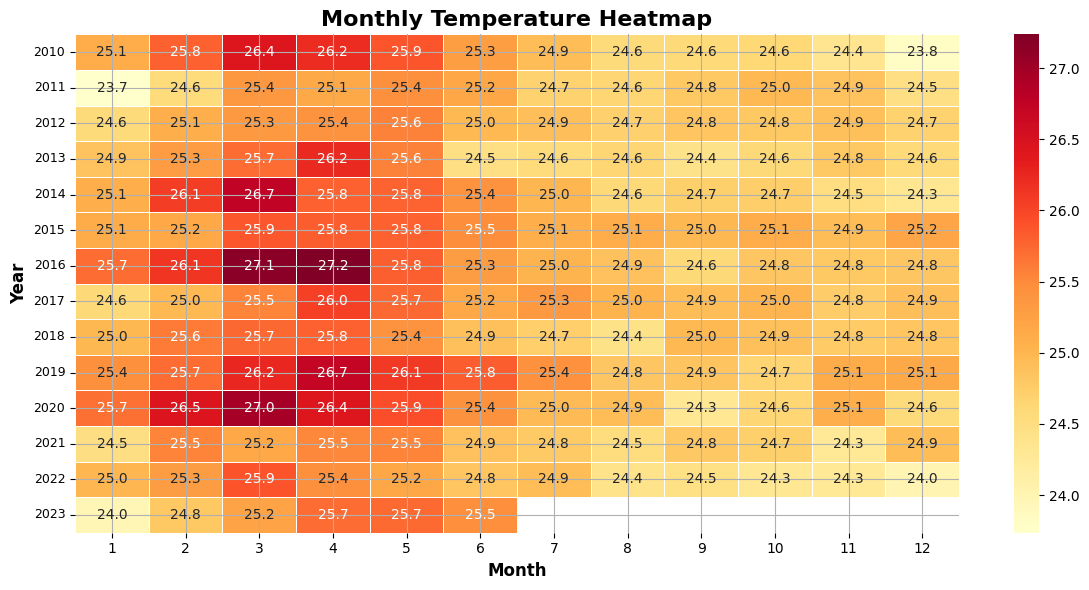

In [78]:
heatmap_ = average_temp.pivot(index='year', columns='month', values='temperature_2m_mean')

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_ , cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5)
plt.title('Monthly Temperature Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0, fontsize=9)
plt.show()

# **Prophet for Temperature**

In [79]:
train = weather_ratnapura['temperature_2m_mean'].reset_index()
#ds - Date , y - value
train.columns = ['ds', 'y']

#get data from 2020-2022
train = train[(train['ds'] >= '2020-01-01' ) & (train['ds'] <= '2022-12-31')]
print(f"Length of data: {len(train)}")
train.head()

Length of data: 1096


,ds,y
3652,2020-01-01,25.5
3653,2020-01-02,25.2
3654,2020-01-03,25.7
3655,2020-01-04,25.5
3656,2020-01-05,25.5


In [80]:
T_model = Prophet (
    yearly_seasonality=10,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale= 0.01, #lower means better
    n_changepoints=10
)

T_model.fit(train)

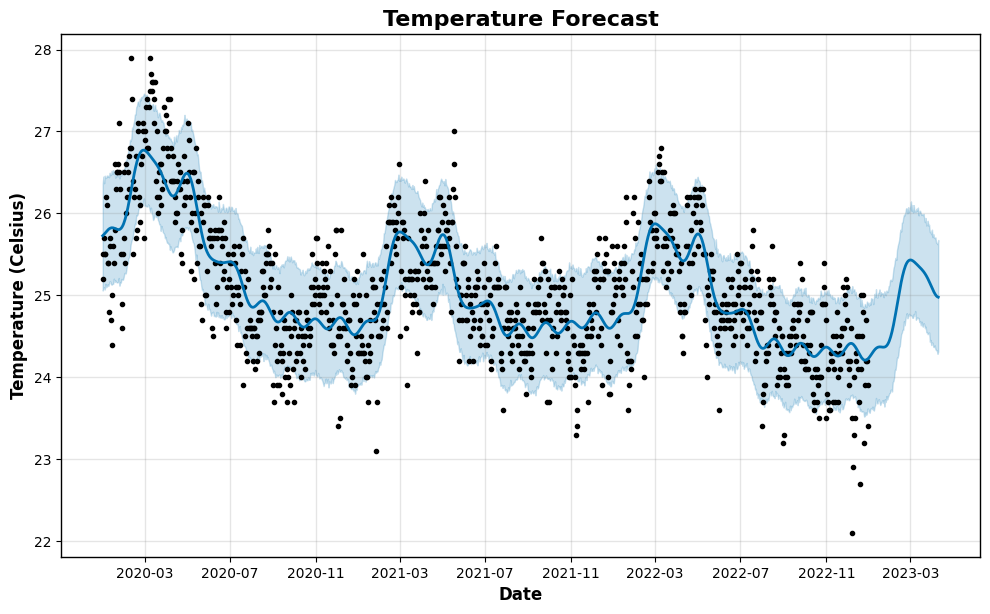

In [81]:
#Forcasting temp for 100 days

future_temp = T_model.make_future_dataframe(periods=100, freq='D')
forecast_temp = T_model.predict(future_temp)

fig = T_model.plot(forecast_temp)
plt.title('Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.show()

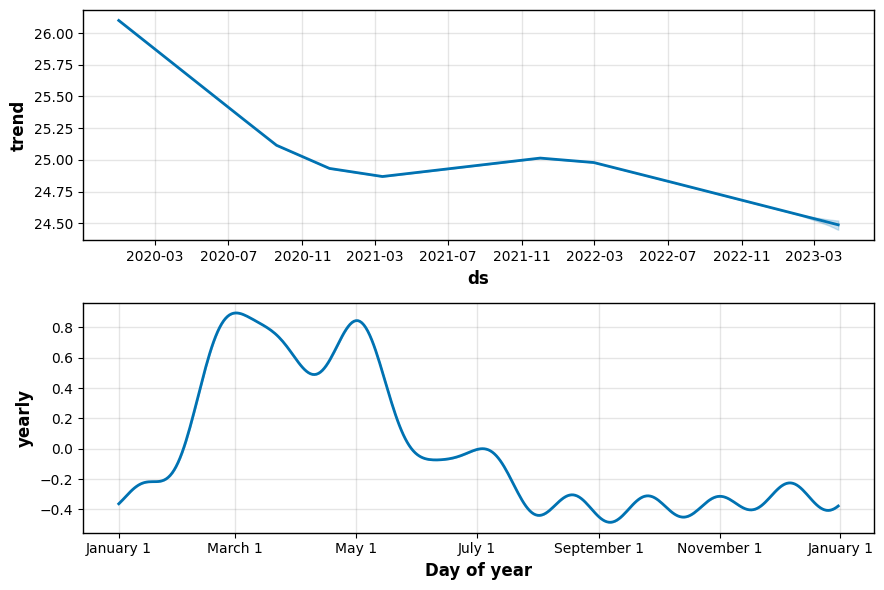

In [82]:
#what prophet learned
figure2 = T_model.plot_components(forecast_temp)
plt.show()

In [83]:
print(weather_ratnapura['temperature_2m_mean'].describe())

count    4916.000000
mean       25.148434
std         0.801504
min        19.800000
25%        24.600000
50%        25.100000
75%        25.600000
max        28.000000
Name: temperature_2m_mean, dtype: float64


# **Rainfall with LightGBM + Lag features**

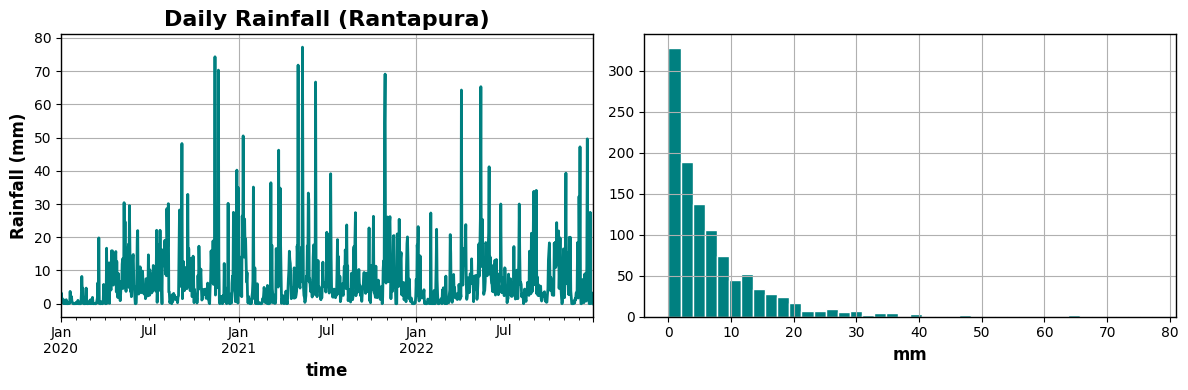

In [84]:
#Rainfall 2020-2022
rain = weather_ratnapura.loc['2020-01-01': '2022-12-31', 'rain_sum'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rain.plot(ax=axes[0], title="Daily Rainfall (Rantapura)", color ='teal')
axes[0].set_ylabel("Rainfall (mm)")
rain.hist(ax=axes[1], bins=40, color='teal', edgecolor = 'white')
axes[1].set_xlabel("Rainfall pattern")
axes[1].set_xlabel('mm')
plt.show()

In [85]:
#Building Lag calender featurer

rain_df = rain.to_frame(name='rain_sum')

#Lag features
for lag in [1, 7, 14, 30]:
  rain_df[f'lag {lag}'] = rain_df['rain_sum'].shift(lag)

  #lag1 : yesterday
  #lag7: last week
  #lag14: last two weeks


#smoothing (rolling) over last 7/30 days (for capturing trends)
rain_df['rolling_7'] = rain_df['rain_sum'].shift().rolling(7).mean()
rain_df['rolling_30'] = rain_df['rain_sum'].shift().rolling(30).mean()

#Calender feature
rain_df['day_of_year'] = rain_df.index.day_of_year



#Drop empty values
rain_df.dropna(inplace=True)

print(f"shape: {rain_df.shape}")
rain_df.head()

shape: (1066, 8)


,rain_sum,lag 1,lag 7,lag 14,lag 30,rolling_7,rolling_30,day_of_year
time,,,,,,,,
2020-01-31,0.0,0.0,0.4,0.3,0.4,0.100000,0.640000,31
2020-02-01,0.4,0.0,0.3,0.3,3.2,0.042857,0.626667,32
2020-02-02,0.1,0.4,0.0,0.1,1.0,0.057143,0.533333,33
2020-02-03,0.0,0.1,0.0,3.7,1.5,0.071429,0.503333,34
2020-02-04,0.1,0.0,0.0,0.6,0.6,0.071429,0.453333,35


In [86]:
#Splitting Data

#getting columns other than rain_sum
feature_colmns = [c for c in rain_df.columns if c != 'rain_sum']

train_set = rain_df[rain_df.index.year <= 2021]
test_set = rain_df[rain_df.index.year == 2022]

X_train, Y_train = train_set[feature_colmns], train_set['rain_sum']
X_test, Y_test = test_set[feature_colmns], test_set['rain_sum']

print(f"Train set: {len(X_train)}")
print(f"Test set: {len(X_test)}")


Train set: 701
Test set: 365


In [87]:
#Train LightGBM

rain_model = lgb.LGBMRegressor(
    n_estimators= 500,
    learning_rate= 0.05,
    num_leaves= 31,
    min_child_samples= 20,
    random_state= 42,
    verbose = -1 #to hide training logs
)


rain_model.fit( X_train, Y_train ,
               eval_set=[(X_test, Y_test)] #moniter the model
               )
print("Model Training Completed")

Model Training Completed


In [88]:
#Evaluate the model

y_pred = rain_model.predict(X_test)
y_pred = np.clip(y_pred, a_min=0, a_max=None) #because rainfall cannot be negative


mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

MAE: 7.04
MSE: 104.77


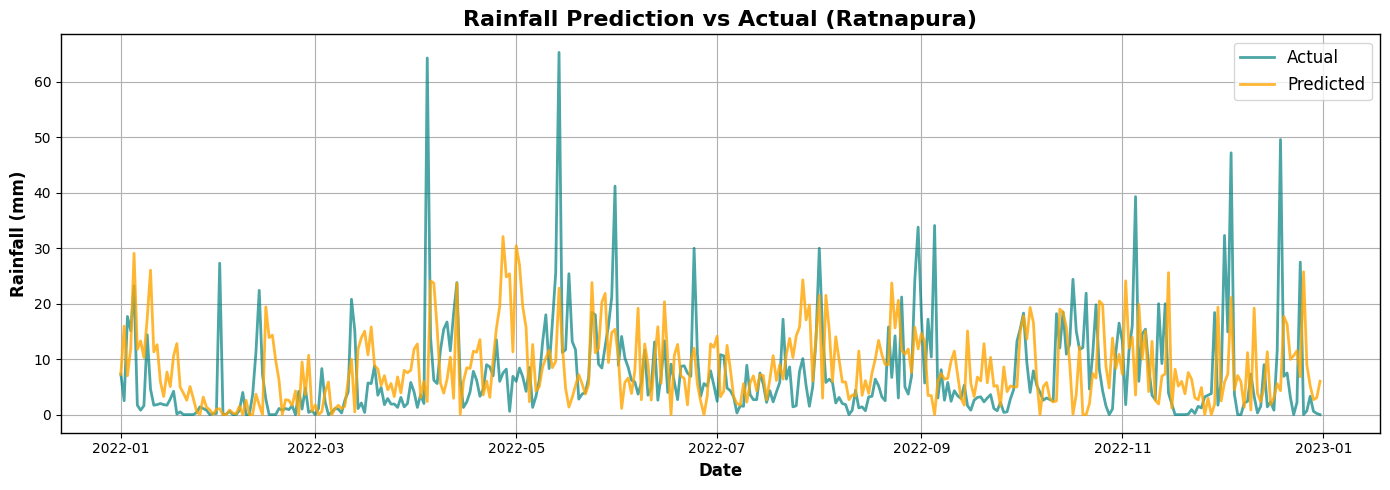

In [89]:
predict_series = pd.Series(y_pred, index=Y_test.index)

plt.figure(figsize=(14, 5))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='teal', alpha=0.7)
plt.plot(predict_series.index, predict_series.values, label='Predicted', color='orange', alpha=0.8)
plt.title('Rainfall Prediction vs Actual (Ratnapura)')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

/tmp/ipykernel_4403/93820598.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


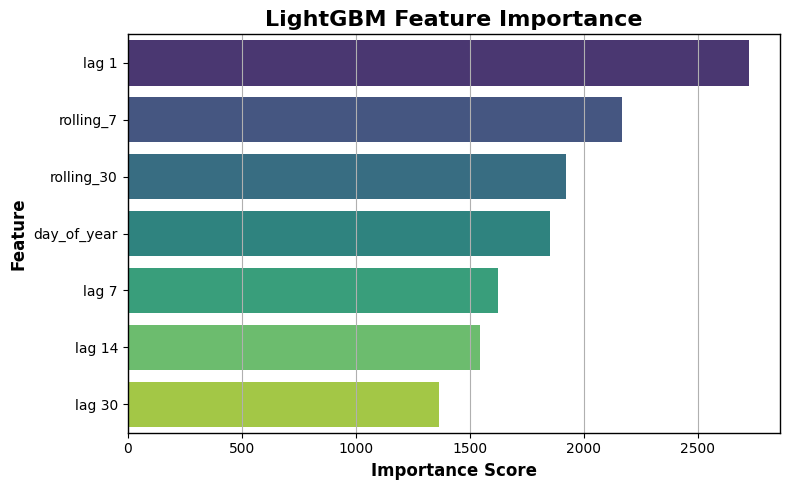

In [90]:
#Checking feature importance

importance_df = pd.DataFrame({
    'feature':    feature_colmns,
    'importance': rain_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

since month is nealy useless. Dropped month and added monsoon features

removed monsoon features because model is already knows about seasonlity